In [15]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

from scipy.stats import linregress

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

from studio_preprocessing_tools import *

In [16]:
pho4_wt = 'MGRTTSEGIHGFVDDLEPKSSILDKVGDFITVNTKRHDGREDFNEQNDELNSQENHNSSENGNENENEQDSLALDDLDRAFELVEGMDMDWMMPSHAHHSPATTATIKPRLLYSPLIHTQSAVPVTISPNLVATATSTTSANKVTKNKSNSSPYLNKRRGKPGPDSATSLFELPDSVIPTPKPKPKPKQYPKVILPSNSTRRVSPVTAKTSSSAEGVVVASESPVIAPHGSSHSRSLSKRRSSGALVDDDKRESHKHAEQARRNRLAVALHELASLIPAEWKQQNVSAAPSKATTVEAACRYIRHLQQNVST'

dna_sequences = ['CCACGTGA', 'ACACGTGA', 'CCACGCGA', 'TCACGTGC', 'CACGTT', 'CATGTG', 'CAACGTG', 'GCACGTGC', 'CGCGTG']

dfs = {}
for dna_seq in dna_sequences:
    csv_filename = f"../../pg2/DMS_assays/raw_data/PHO4_YEAST_Aditham_2021/PHO4_Kd_{dna_seq}_100mM_NaCl.csv"
    df = pd.read_csv(csv_filename, index_col=0)
    
    df = df[['id', 'ddG_wt', 'estimate']]

    # Assuming your dataframe is called `df`
    # Group by 'id' and aggregate mean and SEM
    summary_df = df.groupby('id').agg({
        'ddG_wt': ['mean', sem],
        'estimate': ['mean', sem]
    })
    
    # Flatten the MultiIndex columns
    summary_df.columns = ['ddG_wt_mean', 'ddG_wt_sem', 'Kd_mean', 'Kd_sem']

    summary_df['aa_sequence'] = [apply_mutations(pho4_wt, _id) for _id in summary_df.index] 
    
    dfs[dna_seq.split('_')[0]] = summary_df

multiindex_df = pd.concat(dfs, names=["DNA_seq", "id"])
multiindex_df

/home/sb611/.conda/envs/evcouplings_new/lib/python3.11/site-packages/pandas/core/groupby/generic.py:324: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f = lambda x: func(x, *args, **kwargs)
/home/sb611/.conda/envs/evcouplings_new/lib/python3.11/site-packages/pandas/core/groupby/generic.py:324: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f = lambda x: func(x, *args, **kwargs)
/home/sb611/.conda/envs/evcouplings_new/lib/python3.11/site-packages/pandas/core/groupby/generic.py:324: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f = lambda x: func(x, *args, **kwargs)
/home/sb611/.conda/envs/evcouplings_new/lib/python3.11/site-packages/pandas/core/groupby/generic.py:324: SmallSampleWarning: One o

ddG_wt_mean  ddG_wt_sem       Kd_mean       Kd_sem  \
DNA_seq  id                                                          
CCACGTGA A245V    -0.069392    0.016554    527.863301    72.617400   
         A258L     0.955581    0.061147   2700.975148   375.849816   
         A258R     0.589342    0.041047   1450.689782   170.759111   
         A258V     1.453271    0.099027   4679.387605   354.689899   
         A261V     0.564451    0.072752   1267.931652   180.145451   
...                     ...         ...           ...          ...   
CGCGTG   W281V     0.217038    0.038232  23478.967814  1708.168310   
         WT       -0.014645    0.024600  16280.205282   728.124578   
         Y302A     0.862973    0.065568  72303.970147  8232.436589   
         Y302H     0.806997    0.040180  61370.849181  2421.567322   
         Y302V     0.620751    0.031795  48869.315821  3060.203703   

                                                      aa_sequence  
DNA_seq  id                                                        
CCACGTGA A245V  MGRTTSEGIHGFVDDLEPKSSILDKVGDFITVNTKRHDGREDFNEQ...  
         A258L  MGRTTSEGIHGFVDDLEPKSSILDKVGDFITVNTKRHDGREDFNEQ...  
         A258R  MGRTTSEGIHGFVDDLEPKSSILDKVGDFITVNTKRHDGREDFNEQ...  
         A258V  MGRTTSEGIHGFVDDLEPKSSILDKVGDFITVNTKRHDGREDFNEQ...  
         A261V  MGRTTSEGIHGFVDDLEPKSSILDKVGDFITVNTKRHDGREDFNEQ...  
...                                                           ...  
CGCGTG   W281V  MGRTTSEGIHGFVDDLEPKSSILDKVGDFITVNTKRHDGREDFNEQ...  
         WT     MGRTTSEGIHGFVDDLEPKSSILDKVGDFITVNTKRHDGREDFNEQ...  
         Y302A  MGRTTSEGIHGFVDDLEPKSSILDKVGDFITVNTKRHDGREDFNEQ...  
         Y302H  MGRTTSEGIHGFVDDLEPKSSILDKVGDFITVNTKRHDGREDFNEQ...  
         Y302V  MGRTTSEGIHGFVDDLEPKSSILDKVGDFITVNTKRHDGREDFNEQ...  

[1865 rows x 5 columns]

Text(0, 0.5, 'ddG (CACGTT)')

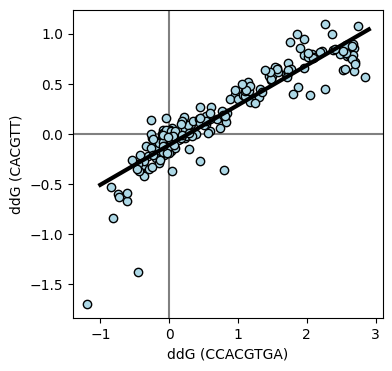

In [17]:
lig1 = "CCACGTGA"
lig2 = "CACGTT"

# Extract ddG_mean for each ligand
ddg1 = multiindex_df.loc[lig1, "ddG_wt_mean"]
ddg2 = multiindex_df.loc[lig2, "ddG_wt_mean"]

ddg_compare = pd.DataFrame({
    lig1: ddg1,
    lig2: ddg2
}).dropna()  # Drop any IDs not present in both

m, b, _, _, _ = linregress(ddg_compare[lig1], ddg_compare[lig2])

plt.figure(figsize=(4,4))

x = np.arange(-1, 3, 0.1)
plt.plot(x, m*x + b, c='k', lw=3)

intersections, d = perpendicular_intersection_and_distance(m, b, ddg_compare[lig1], ddg_compare[lig2])

x_coord_intersections = intersections[0]
d_active = d[x_coord_intersections>3.3]

plt.axvline(0, c='gray', zorder=-10); plt.axhline(0, c='gray', zorder=-10)
plt.scatter(ddg_compare[lig1], ddg_compare[lig2], ec='k', c='lightblue')
plt.xlabel(f"ddG ({lig1})")
plt.ylabel(f"ddG ({lig2})")

In [18]:
def extract_pairwise_comparison(multiindex_df, lig1, lig2):

    ddg1 = multiindex_df.loc[lig1, "ddG_wt_mean"]
    ddg2 = multiindex_df.loc[lig2, "ddG_wt_mean"]

    ddg_compare = pd.DataFrame({
        lig1: ddg1,
        lig2: ddg2
    }).dropna()

    return ddg_compare

def linear_ddG_analysis(data, x, y):

    df = extract_pairwise_comparison(data, x, y)
    
    m, b, r, p, _ = linregress(df[x], df[y])

    intersections, d = perpendicular_intersection_and_distance(m, b, df[x], df[y])
    
    return (m, b), intersections, d

linear_fits = []
x_intersection_coords = []
distances_from_line = []

for lig2 in dna_sequences[1:]:
    
    fit, intcoor, dfl = linear_ddG_analysis(multiindex_df, "CCACGTGA", lig2)

    linear_fits.append(fit)
    x_intersection_coords.append(intcoor[0].rename(lig2))
    distances_from_line.append(dfl.rename(lig2))

pho4_specificity_residuals = pd.concat(distances_from_line, axis=1)
pho4_reg_ddG_score = pd.concat(x_intersection_coords, axis=1)
linear_fits = pd.DataFrame(linear_fits, columns=("slope", "intercept"), index=dna_sequences[1:])

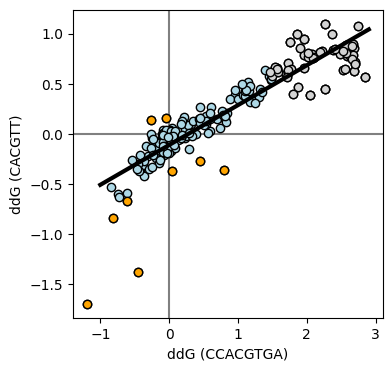

In [19]:
plt.figure(figsize=(4,4))

df = extract_pairwise_comparison(multiindex_df, "CCACGTGA", "CACGTT")

plt.axvline(0, c='gray', zorder=-10); plt.axhline(0, c='gray', zorder=-10)
plt.scatter(df["CCACGTGA"], df["CACGTT"], ec='k', c='lightblue')
plt.xlabel(f"ddG (CCACGTGA)")
plt.ylabel(f"ddG (CACGTT)")

x = np.arange(-1, 3, 0.1)
plt.plot(x, linear_fits.loc['CACGTT'].slope*x + linear_fits.loc['CACGTT'].intercept, c='k', lw=3)
altered_specificity = pho4_specificity_residuals.loc[df.index]['CACGTT']>0.25
plt.scatter(df.loc[altered_specificity]['CCACGTGA'], df.loc[altered_specificity]['CACGTT'], c='orange', ec='k')
inactive = pho4_reg_ddG_score.loc[df.index]['CACGTT']>1.5
plt.scatter(df.loc[inactive]['CCACGTGA'], df.loc[inactive]['CACGTT'], c='lightgray', ec='k')

plt.savefig("Pho4_example_regplot.pdf", bbox_inches="tight")

<Axes: xlabel='global_ddG', ylabel='max_specificity_residual'>

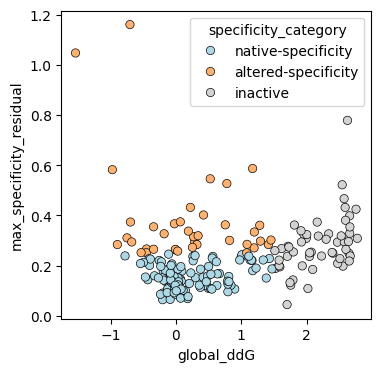

In [20]:
mean_global_ddG = pho4_reg_ddG_score.mean(axis=1)

pho4_analysis_summary = pd.concat([mean_global_ddG.rename("global_ddG"), pho4_specificity_residuals.max(axis=1).rename("max_specificity_residual")], axis=1)
pho4_analysis_summary = assign_specificity_categories(pho4_analysis_summary,
                              lambda index,row: row.global_ddG>1.5,
                              lambda index,row: row.max_specificity_residual>0.25)

plt.figure(figsize=(4,4))
sns.scatterplot(data=pho4_analysis_summary,
             x="global_ddG", y="max_specificity_residual", hue="specificity_category", ec='k',
               palette=gentle_palette)

#plt.savefig("Pho4_global_ddG.pdf", bbox_inches='tight')

In [21]:
len("MWFGEFGGQYVPETLVGPLKELEKAYKRFKDDEEFNRQLNYYLKTWAGRPTPLYYAKRLTEKIGGAKVYLKREDLVHGGAHKTNNAIGQALLAKLMGKTRLIAETGAGQHGVATAMAGALLGMKVDIYMGAEDVERQKLNVFRMKLLGANVIPVNSGSRTLKDAYDEALRDWVATFEYTHYLVGSVVGPHPYPTIVRDFQSVIGREAKAQIPEAEGQLPDVIVACVGGGSNAMGIFYPFVNDKKVKLVGVEAGGKGLESGKHSASLNAGQVGVSHGMLSYFLQDEEGQIKPSHSIAPGLDGPGVGPEHAYLKKIQRAEYVAVTDEEALKAFHELSRTEGIIPALESAHAVAYAMKLAKEMSRDEIIIVNLSGRGDKDLDIVLKASGNVTIDKAIEAKREGKEIVILFNLSGHGLLDLHGYEEYLEGRLQDYEPKDLPISNPLNPKP")

446

In [22]:
pho4_dataset = pd.concat([multiindex_df['ddG_wt_mean'].unstack().T,
                          pho4_analysis_summary], axis=1)
pho4_dataset = assign_mutant_column(pho4_dataset)
pho4_dataset['n_subs'] = [i.count(':')+1 if i!='M1M' else 0 for i in pho4_dataset.mutant]
pho4_dataset['mutated_sequence'] = [apply_mutations(pho4_wt, muts) for muts in pho4_dataset.mutant]
pho4_dataset['DMS_score'] = pho4_dataset['CCACGTGA']

check_dataset(pho4_dataset)

pho4_dataset.to_csv("../../processed_data/PHO4_YEAST_Aditham_2021.csv")

Checking dataset table:
✅ DMS_score in table
✅ mutated_sequence in table
✅ mutant in table
✅ Contains WT sequence (M1M)
✅ all mutants pass checks and match sequence

✅ All checks passed!


In [29]:
pho4_singles

,CCACGTGA,ACACGTGA,CCACGCGA,TCACGTGC,CACGTT,CATGTG,CAACGTG,GCACGTGC,CGCGTG,global_ddG,max_specificity_residual,specificity_category,mutant,n_subs,mutated_sequence,DMS_score,pos
id,,,,,,,,,,,,,,,,,
A245V,-0.069392,0.092109,NaN,0.155113,NaN,-0.045298,-0.081124,-0.203568,-0.229780,-0.054064,0.152611,native-specificity,A245V,1,MGRTTSEGIHGFVDDLEPKSSILDKVGDFITVNTKRHDGREDFNEQ...,-0.069392,245
A258L,0.955581,0.744510,0.351069,1.076170,0.387726,0.391706,0.320118,0.874877,0.216852,0.999060,0.233795,native-specificity,A258L,1,MGRTTSEGIHGFVDDLEPKSSILDKVGDFITVNTKRHDGREDFNEQ...,0.955581,258
A258R,0.589342,0.141581,0.060626,-0.167256,0.024267,0.146176,0.073689,0.579713,-0.105153,0.524702,0.545795,altered-specificity,A258R,1,MGRTTSEGIHGFVDDLEPKSSILDKVGDFITVNTKRHDGREDFNEQ...,0.589342,258
A258V,1.453271,0.808339,0.381641,1.128721,0.581524,0.398602,0.447223,NaN,0.206804,1.428617,0.227923,native-specificity,A258V,1,MGRTTSEGIHGFVDDLEPKSSILDKVGDFITVNTKRHDGREDFNEQ...,1.453271,258
A261V,0.564451,0.546489,0.062704,0.788752,0.010682,0.135803,0.127175,0.148633,-0.006822,0.564893,0.236390,native-specificity,A261V,1,MGRTTSEGIHGFVDDLEPKSSILDKVGDFITVNTKRHDGREDFNEQ...,0.564451,261
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
W281A,0.951502,0.908116,0.382058,0.797833,0.437841,0.407838,0.398611,0.446762,0.359958,0.974619,0.222213,native-specificity,W281A,1,MGRTTSEGIHGFVDDLEPKSSILDKVGDFITVNTKRHDGREDFNEQ...,0.951502,281
W281V,0.592838,0.693943,0.179463,0.635041,0.212049,0.222031,0.288549,0.171349,0.217038,0.618622,0.215079,native-specificity,W281V,1,MGRTTSEGIHGFVDDLEPKSSILDKVGDFITVNTKRHDGREDFNEQ...,0.592838,281
Y302A,2.261019,1.884044,0.869377,1.826248,1.098816,0.889282,0.983142,1.463029,0.862973,2.296323,0.304858,inactive,Y302A,1,MGRTTSEGIHGFVDDLEPKSSILDKVGDFITVNTKRHDGREDFNEQ...,2.261019,302


In [40]:
pho4_singles

,CCACGTGA,ACACGTGA,CCACGCGA,TCACGTGC,CACGTT,CATGTG,CAACGTG,GCACGTGC,CGCGTG,global_ddG,max_specificity_residual,specificity_category,mutant,n_subs,mutated_sequence,DMS_score,pos,altered-specificity
id,,,,,,,,,,,,,,,,,,
A245V,-0.069392,0.092109,NaN,0.155113,NaN,-0.045298,-0.081124,-0.203568,-0.229780,-0.054064,0.152611,native-specificity,A245V,1,MGRTTSEGIHGFVDDLEPKSSILDKVGDFITVNTKRHDGREDFNEQ...,-0.069392,245,False
A258L,0.955581,0.744510,0.351069,1.076170,0.387726,0.391706,0.320118,0.874877,0.216852,0.999060,0.233795,native-specificity,A258L,1,MGRTTSEGIHGFVDDLEPKSSILDKVGDFITVNTKRHDGREDFNEQ...,0.955581,258,False
A258R,0.589342,0.141581,0.060626,-0.167256,0.024267,0.146176,0.073689,0.579713,-0.105153,0.524702,0.545795,altered-specificity,A258R,1,MGRTTSEGIHGFVDDLEPKSSILDKVGDFITVNTKRHDGREDFNEQ...,0.589342,258,True
A258V,1.453271,0.808339,0.381641,1.128721,0.581524,0.398602,0.447223,NaN,0.206804,1.428617,0.227923,native-specificity,A258V,1,MGRTTSEGIHGFVDDLEPKSSILDKVGDFITVNTKRHDGREDFNEQ...,1.453271,258,False
A261V,0.564451,0.546489,0.062704,0.788752,0.010682,0.135803,0.127175,0.148633,-0.006822,0.564893,0.236390,native-specificity,A261V,1,MGRTTSEGIHGFVDDLEPKSSILDKVGDFITVNTKRHDGREDFNEQ...,0.564451,261,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
W281A,0.951502,0.908116,0.382058,0.797833,0.437841,0.407838,0.398611,0.446762,0.359958,0.974619,0.222213,native-specificity,W281A,1,MGRTTSEGIHGFVDDLEPKSSILDKVGDFITVNTKRHDGREDFNEQ...,0.951502,281,False
W281V,0.592838,0.693943,0.179463,0.635041,0.212049,0.222031,0.288549,0.171349,0.217038,0.618622,0.215079,native-specificity,W281V,1,MGRTTSEGIHGFVDDLEPKSSILDKVGDFITVNTKRHDGREDFNEQ...,0.592838,281,False
Y302A,2.261019,1.884044,0.869377,1.826248,1.098816,0.889282,0.983142,1.463029,0.862973,2.296323,0.304858,inactive,Y302A,1,MGRTTSEGIHGFVDDLEPKSSILDKVGDFITVNTKRHDGREDFNEQ...,2.261019,302,False


In [41]:
258 -250

8

In [39]:
pho4_wt.find('KRESH')

250

In [63]:
def get_specificity_positions(df):
    sp_muts = selector(df, {'specificity_category': 'altered-specificity', 'n_subs':1}).mutant
    return pd.Series([i[1:-1] for i in sp_muts]).value_counts()

pho4_singles = pho4_dataset.loc[pho4_dataset.n_subs==1]
pho4_singles['pos'] = [int(i[1:-1])-250 for i in pho4_singles.index]
pho4_singles['altered-specificity'] = pho4_singles.specificity_category == 'altered-specificity'
pho4_singles = pho4_singles[pho4_singles.pos > 0]

pho4_singles['count'] = 1
sum_altsp = pho4_singles.groupby('pos').sum(['altered-specificity', 'count'])[['altered-specificity', 'count']]
mean_altsp = sum_altsp['altered-specificity']/(sum_altsp['count'] + 0.5)
altsp = mean_altsp.loc[mean_altsp>0]

print(f"create Pho4_spec, Pho4 and name CA and chain B and resi {'+'.join([str(i) for i in altsp.index])}")

print('color marine, Pho4_spec')

for pos,n in altsp.items():
    print(f"set sphere_scale, {n*2}, Pho4_spec and res {pos};")

create Pho4_spec, Pho4 and name CA and chain B and resi 1+4+5+6+7+8+10+12+17+18+26+29+30+33+35+39+40+41+43+45+46+49+50+54+56
color marine, Pho4_spec
set sphere_scale, 1.3333333333333333, Pho4_spec and res 1;
set sphere_scale, 0.8, Pho4_spec and res 4;
set sphere_scale, 1.3333333333333333, Pho4_spec and res 5;
set sphere_scale, 0.4444444444444444, Pho4_spec and res 6;
set sphere_scale, 1.3333333333333333, Pho4_spec and res 7;
set sphere_scale, 0.5714285714285714, Pho4_spec and res 8;
set sphere_scale, 0.6153846153846154, Pho4_spec and res 10;
set sphere_scale, 0.26666666666666666, Pho4_spec and res 12;
set sphere_scale, 1.3333333333333333, Pho4_spec and res 17;
set sphere_scale, 1.3333333333333333, Pho4_spec and res 18;
set sphere_scale, 1.1428571428571428, Pho4_spec and res 26;
set sphere_scale, 1.3333333333333333, Pho4_spec and res 29;
set sphere_scale, 1.6, Pho4_spec and res 30;
set sphere_scale, 0.5714285714285714, Pho4_spec and res 33;
set sphere_scale, 0.8, Pho4_spec and res 35;
s

/tmp/ipykernel_3050336/1390759969.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pho4_singles['pos'] = [int(i[1:-1])-250 for i in pho4_singles.index]
/tmp/ipykernel_3050336/1390759969.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pho4_singles['altered-specificity'] = pho4_singles.specificity_category == 'altered-specificity'


In [62]:
pho4_singles = pho4_dataset.loc[pho4_dataset.n_subs==1]
pho4_singles['pos'] = [int(i[1:-1]) for i in pho4_singles.index]
pho4_singles['altered-specificity'] = pho4_singles.specificity_category == 'altered-specificity'
pho4_singles = pho4_singles[pho4_singles.pos < 251]

pho4_singles['count'] = 1
sum_altsp = pho4_singles.groupby('pos').sum(['altered-specificity', 'count'])[['altered-specificity', 'count']]
mean_altsp = sum_altsp['altered-specificity']/(sum_altsp['count'] + 0.5)
altsp = mean_altsp.loc[mean_altsp>0]

print(f"create Pho4_AF_spec, AF-P07270-F1-model_v6 and name CA and resi {'+'.join([str(i) for i in altsp.index])}")

print('color marine, Pho4_AF_spec')

for pos,n in altsp.items():
    print(f"set sphere_scale, {n*2}, Pho4_AF_spec and res {pos};")

create Pho4_AF_spec, AF-P07270-F1-model_v6 and name CA and resi 231+233+250
color marine, Pho4_AF_spec
set sphere_scale, 0.8, Pho4_AF_spec and res 231;
set sphere_scale, 0.8, Pho4_AF_spec and res 233;
set sphere_scale, 0.5333333333333333, Pho4_AF_spec and res 250;


/tmp/ipykernel_3050336/72258969.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pho4_singles['pos'] = [int(i[1:-1]) for i in pho4_singles.index]
/tmp/ipykernel_3050336/72258969.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pho4_singles['altered-specificity'] = pho4_singles.specificity_category == 'altered-specificity'


In [61]:
sum_altsp['altered-specificity']/(sum_altsp['count'] + 0.5)

pos
230    0.000000
231    0.400000
232    0.000000
233    0.400000
234    0.000000
235    0.000000
236    0.000000
237    0.000000
238    0.000000
239    0.000000
240    0.000000
241    0.000000
242    0.000000
243    0.000000
244    0.000000
245    0.000000
246    0.000000
247    0.000000
248    0.000000
249    0.000000
250    0.266667
dtype: float64

In [47]:
mean_altsp

pos
1     0.75
2     0.00
3     0.00
4     0.50
5     0.75
      ... 
58    0.00
59    0.00
60    0.00
61    0.00
62    0.00
Name: altered-specificity, Length: 62, dtype: float64

In [43]:
np.mean(mean_altsp)

0.20395869191049912

In [34]:
np.any(mean_altsp>0)

False

In [24]:
mean_altsp

pos
1      0.0
230    0.0
231    0.5
232    0.0
233    0.5
      ... 
308    0.0
309    0.0
310    0.0
311    0.0
312    0.0
Name: altered-specificity, Length: 84, dtype: float64

In [9]:
pho4_dataset.loc[pho4_dataset.mutant=='M1M']

,CCACGTGA,ACACGTGA,CCACGCGA,TCACGTGC,CACGTT,CATGTG,CAACGTG,GCACGTGC,CGCGTG,global_ddG,max_specificity_residual,specificity_category,mutant,n_subs,mutated_sequence,DMS_score
id,,,,,,,,,,,,,,,,
WT,-0.013719,-0.009884,0.005187,0.0314,-0.0297,0.014264,0.009767,-0.031717,-0.014645,0.004884,0.099122,native-specificity,M1M,0,MGRTTSEGIHGFVDDLEPKSSILDKVGDFITVNTKRHDGREDFNEQ...,-0.013719


In [10]:
np.savetxt('../../processed_data/pho4_ESCOTT.mut', pho4_dataset.mutant.values, fmt="%s")
np.savetxt('../../processed_data/pho4_GEMME.mut', [i.replace(':',',') for i in pho4_dataset.mutant.values], fmt="%s")

# Scoring with EVcouplings

In [15]:
import numpy as np
from numba import jit

def DCAEnergy(s, model, independent=False):

    '''DCA energy function that can take in numeric or one-hot encoded sequences.

    Parameters
    ----------
    s: a protein sequence, either a numpy array of length L or a
            one-hot encoded array of length 20*L
    model: a CouplingsModel object (the DCA model to score with)

    optional:
        independent : calculate without couplings terms (using only h_i); defaults to FALSE
        one_hot : whether the input sequence is one-hot encoded (defaults to FALSE)

    Returns
    -------
    E : the DCA energy of the sequence
    '''

    return potts_model_hamiltonian(s, model.h_i, model.J_ij, independent=independent)


@jit(nopython=True)
def potts_model_hamiltonian(seq, hi, Jij, independent=False):

    ''' This jit-compiled function does the actual math because it's faster '''

    E = 0

    for i,x in enumerate(seq):

        E += hi[(i,x)]

        if not independent:
            for j,y in enumerate(seq[:i]):

                E += Jij[(i, j, x, y)]

    return E

def map_to_alphabet(sequence, alphabet):

    return np.array([np.where(alphabet==i)[0][0] for i in sequence])

def EVmutation_score_sequences(model, df, seq_col="aa_seq", wt_id="WT", offset=1):

    ind_model = model.to_independent_model()
    
    seqs_num = np.array([map_to_alphabet(seq, model.alphabet) for seq in df[seq_col]])

    ind_energies = pd.Series([DCAEnergy(s[ind_model.index_list-offset], ind_model) for s in seqs_num], index=df.index, name="independent_energy")
    dca_energies = pd.Series([DCAEnergy(s[model.index_list-offset], model) for s in seqs_num], index=df.index, name="couplings_energy")

    ind_scores = ind_energies - ind_energies.loc['WT']
    dca_scores = dca_energies - dca_energies.loc['WT']
    
    return pd.concat([ind_energies, dca_energies, ind_scores.rename("independent_score"), dca_scores.rename("couplings_score")], axis=1)
    

In [ ]:
s

In [18]:
from evcouplings.couplings import CouplingsModel
model = CouplingsModel("../../EVcouplings/models/PHO4_YEAST_Aditham_2021.model")

In [116]:
print(pho4_wt.find(''.join(model.target_seq[:20])))
scores = EVmutation_score_sequences(model, pho4_dataset, offset=-249, seq_col="mutated_sequence")

252


In [106]:
pho4_wt.find(''.join(model.target_seq[:20]))

252

In [103]:
model.target_seq[model.index_list==6]

array(['K'], dtype='<U1')

In [111]:
s = np.array(list(pho4_dataset.mutated_sequence.loc['A245V']))

In [115]:
s[model.index_list+249]

array(['E', 'S', 'H', 'K', 'H', 'A', 'E', 'Q', 'A', 'R', 'R', 'N', 'R',
       'L', 'A', 'V', 'A', 'L', 'H', 'E', 'L', 'A', 'S', 'L', 'I', 'P',
       'Q', 'N', 'V', 'S', 'A', 'A', 'P', 'S', 'K', 'A', 'T', 'T', 'V',
       'E', 'A', 'A', 'C', 'R', 'Y', 'I', 'R', 'H', 'L'], dtype='<U1')

In [114]:
model.target_seq

array(['E', 'S', 'H', 'K', 'H', 'A', 'E', 'Q', 'A', 'R', 'R', 'N', 'R',
       'L', 'A', 'V', 'A', 'L', 'H', 'E', 'L', 'A', 'S', 'L', 'I', 'P',
       'Q', 'N', 'V', 'S', 'A', 'A', 'P', 'S', 'K', 'A', 'T', 'T', 'V',
       'E', 'A', 'A', 'C', 'R', 'Y', 'I', 'R', 'H', 'L'], dtype='<U1')

In [118]:
scores['pos'] = [int(i[1:-1]) if i!='WT' else np.nan for i in scores.index]

In [119]:
sele_str = (np.isin(scores['pos']-249, model.index_list)==False)&(scores.index!='WT')
scores.loc[sele_str, ['independent_score', 'couplings_score']] = np.ones((np.sum(sele_str), 2))*np.nan

In [125]:
scores['mutant'] = scores.index
scores.to_csv("../../model_scores/EVmutation/PHO4_YEAST_Aditham_2021.csv")

In [120]:
X = pd.concat([pho4_dataset, scores], axis=1).dropna()

from scipy.stats import spearmanr
spearmanr(-X.global_ddG, X.couplings_score)

SignificanceResult(statistic=0.6916856840107689, pvalue=2.21405404551287e-17)

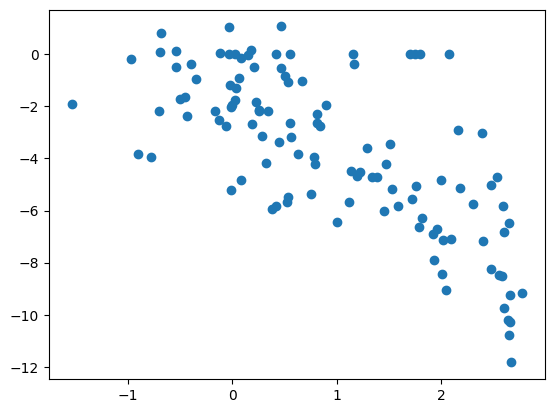

In [121]:
plt.scatter(X.global_ddG, X.couplings_score)

In [123]:
from scipy.stats import spearmanr
spearmanr(-X.global_ddG, X.independent_score)

SignificanceResult(statistic=0.7211777066926646, pvalue=2.0930670440152213e-19)

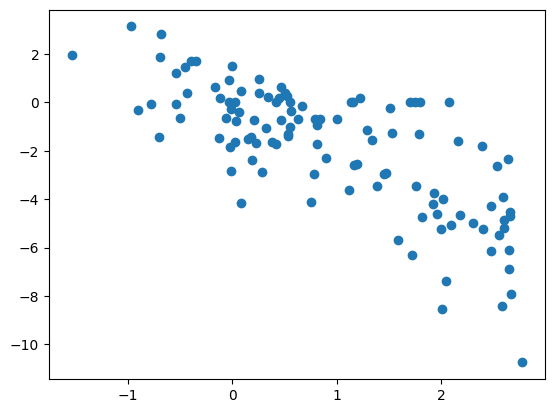

In [122]:
plt.scatter(X.global_ddG, X.independent_score)